# Spotter Freight Rate Prediction - Data Audit

## 1. Dataset Overview

This notebook audits the datasets provided for the Spotter freight rate prediction problem:
- `train-test.csv`: Historical load records with freight rates and features.
- `validation.csv`: Evaluation load records requiring rate predictions.
- `december-chart-inputs.csv`: 31 daily load inputs for a fixed December lane.
- `validation-predictions-template.csv`: Format template for prediction submissions.

The goal is to inspect data shapes, column types, missing values, unusual values (such as negative weights), the target rate distribution, and categorical feature coverage before model training.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\manso\Desktop\spotter-freight-rate-ml


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("..")
DATA = ROOT / "data"

train = pd.read_csv(DATA / "train-test.csv")
validation = pd.read_csv(DATA / "validation.csv")
december = pd.read_csv(DATA / "december-chart-inputs.csv")
template = pd.read_csv(DATA / "validation-predictions-template.csv")

print("TRAIN:", train.shape)
print("VALIDATION:", validation.shape)
print("DECEMBER:", december.shape)
print("TEMPLATE:", template.shape)

TRAIN: (48000, 14)
VALIDATION: (12000, 13)
DECEMBER: (31, 7)
TEMPLATE: (12000, 2)


## 2. Dataset Shapes and Schema

Here we inspect the column schema, non-null counts, sample records, and date coverage for each dataset.

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [3]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [4]:
train.columns.tolist()

['load_id',
 'pickup',
 'delivery',
 'pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'distance',
 'equipment',
 'weight',
 'date',
 'market_index',
 'quote_signal',
 'posted_rate']

In [5]:
train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])
december["date"] = pd.to_datetime(december["date"])

print("Train:", train["date"].min(), "to", train["date"].max())
print("Validation:", validation["date"].min(), "to", validation["date"].max())
print("December:", december["date"].min(), "to", december["date"].max())

Train: 2025-01-01 00:00:00 to 2025-10-31 00:00:00
Validation: 2025-11-01 00:00:00 to 2025-12-31 00:00:00
December: 2025-12-01 00:00:00 to 2025-12-31 00:00:00


## 3. Missing Values

We check for missing values across the training data, validation data, and December inputs to identify columns that need imputation.

In [6]:
missing = train.isna().sum().sort_values(ascending=False)
missing[missing > 0]

market_index    374
weight          300
dtype: int64

In [7]:
missing_pct = (train.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

market_index    0.779167
weight          0.625000
dtype: float64

In [16]:
print("VALIDATION MISSING VALUES")
validation_missing = validation.isna().sum().sort_values(ascending=False)
print(validation_missing[validation_missing > 0])

print("\nVALIDATION MISSING %")
validation_missing_pct = (validation.isna().mean() * 100).sort_values(ascending=False)
print(validation_missing_pct[validation_missing_pct > 0])

VALIDATION MISSING VALUES
market_index    249
weight          165
dtype: int64

VALIDATION MISSING %
market_index    2.075
weight          1.375
dtype: float64


In [17]:
print("DECEMBER MISSING VALUES")
print(december.isna().sum())

DECEMBER MISSING VALUES
pickup             0
delivery           0
distance           0
equipment          0
weight             0
date               0
predicted_rate    31
dtype: int64


## 4. Weight Anomalies

During data inspection, a subset of rows showed negative values in the weight column. Here we isolate and examine those rows to understand how frequent they are, which equipment types they affect, and whether their rates look typical.

In [9]:
print("Negative weights:", (train["weight"] < 0).sum())
print("Zero weights:", (train["weight"] == 0).sum())
print("Negative distance:", (train["distance"] < 0).sum())
print("Non-positive target:", (train["posted_rate"] <= 0).sum())

Negative weights: 292
Zero weights: 0
Negative distance: 0
Non-positive target: 0


In [28]:
negative_weight = train[train["weight"] < 0]

print("Negative-weight rows:", len(negative_weight))
print("Percentage:", len(negative_weight) / len(train) * 100)

negative_weight[
    ["weight", "distance", "equipment", "market_index",
     "quote_signal", "posted_rate"]
].describe()

Negative-weight rows: 292
Percentage: 0.6083333333333333


,weight,distance,market_index,quote_signal,posted_rate
count,292.000000,292.000000,289.000000,292.000000,292.000000
mean,-31724.195205,1120.920205,1.096322,2.041966,2389.786233
std,8262.536326,733.132047,0.171562,0.298395,1641.761285
min,-47500.000000,75.100000,0.789880,1.157730,247.370000
25%,-37284.250000,531.975000,0.961550,1.868555,1257.410000
50%,-31821.500000,930.450000,1.065710,2.033965,1994.960000
75%,-25928.500000,1537.125000,1.241320,2.194368,3185.257500
max,-5000.000000,3161.700000,1.431890,3.312330,14561.210000


In [29]:
negative_weight.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
equipment,,,
Dry Van,155,2148.483161,1856.42
Flatbed,70,2678.577857,2236.76
Reefer,67,2646.302090,2558.37


In [30]:
negative_weight.head(20)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,rate_per_mile
68,TR-000069,Amarillo,Dayton,33.17137,-104.36789,39.87206,-85.62931,1334.2,Reefer,-36559.0,2025-01-01,0.96102,2.11777,2831.27,2.122073
204,TR-000205,Fresno,Tucson,33.07921,-119.79528,30.92733,-113.23037,496.2,Dry Van,-26670.0,2025-01-02,0.96903,2.13155,1046.92,2.109875
206,TR-000207,Columbia,Raleigh,34.63570,-83.28506,35.37376,-77.47605,411.3,Reefer,-20003.0,2025-01-02,0.94800,2.31682,959.15,2.331996
225,TR-000226,Greensboro,Lubbock,35.98195,-82.78379,29.87534,-99.85456,1317.4,Reefer,-23981.0,2025-01-02,1.00820,2.13918,2836.00,2.152725
376,TR-000377,Madison,Providence,41.70243,-89.85588,37.37287,-69.50000,1331.1,Dry Van,-41397.0,2025-01-03,0.94787,1.91867,2522.54,1.895079
446,TR-000447,Albuquerque,Albany,35.39918,-109.59792,43.96975,-71.05842,2438.3,Reefer,-37215.0,2025-01-03,0.96575,1.96959,4841.57,1.985633
495,TR-000496,Montgomery,Dayton,31.37602,-86.10743,39.87206,-85.62931,715.9,Dry Van,-31214.0,2025-01-04,0.85153,2.03947,1473.78,2.058639
641,TR-000642,Tulsa,Indianapolis,33.45894,-94.78556,38.52567,-88.85948,582.4,Dry Van,-41023.0,2025-01-05,0.81988,2.22721,1264.33,2.170896
806,TR-000807,Cincinnati,Buffalo,37.15706,-86.77499,41.67681,-78.56704,676.1,Dry Van,-28320.0,2025-01-06,0.79158,1.95680,1307.76,1.934270
1093,TR-001094,Cincinnati,Albany,37.15706,-86.77499,43.96975,-71.05842,1058.5,Dry Van,-25153.0,2025-01-07,0.89891,1.81081,1907.83,1.802390


## 5. Target Distribution

We examine the distribution of the target variable `posted_rate`, rate per mile (`posted_rate / distance`), correlations with other features, and daily and monthly rate patterns over time.

In [11]:
train["posted_rate"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
1%         327.168800
5%         599.738500
25%       1251.555000
50%       2030.760000
75%       3330.750000
95%       4953.766500
99%       5972.834000
max      25533.000000
Name: posted_rate, dtype: float64

In [12]:
train[["distance", "weight", "market_index", "quote_signal", "posted_rate"]].corr()

,distance,weight,market_index,quote_signal,posted_rate
distance,1.000000,0.002544,-0.002181,-0.057244,0.908519
weight,0.002544,1.000000,-0.001331,0.008159,0.034840
market_index,-0.002181,-0.001331,1.000000,-0.067827,0.034165
quote_signal,-0.057244,0.008159,-0.067827,1.000000,-0.039858
posted_rate,0.908519,0.034840,0.034165,-0.039858,1.000000


In [13]:
daily = train.groupby("date")["posted_rate"].agg(
    ["count", "mean", "median", "std"]
)

daily.head()

,count,mean,median,std
date,,,,
2025-01-01,145,2182.959586,1991.870,1193.423009
2025-01-02,168,2223.485595,1885.395,1349.279535
2025-01-03,156,2331.391154,1892.985,1412.795887
2025-01-04,156,2334.728782,1967.150,1534.821331
2025-01-05,154,2041.046688,1626.405,1278.917472


In [14]:
daily.tail()

,count,mean,median,std
date,,,,
2025-10-27,148,2397.204122,1997.100,1929.581592
2025-10-28,131,2420.863511,2095.300,1322.776876
2025-10-29,164,2418.749085,2017.380,1802.173228
2025-10-30,177,2433.295593,1898.300,1586.881219
2025-10-31,176,2245.691023,1906.235,1417.564628


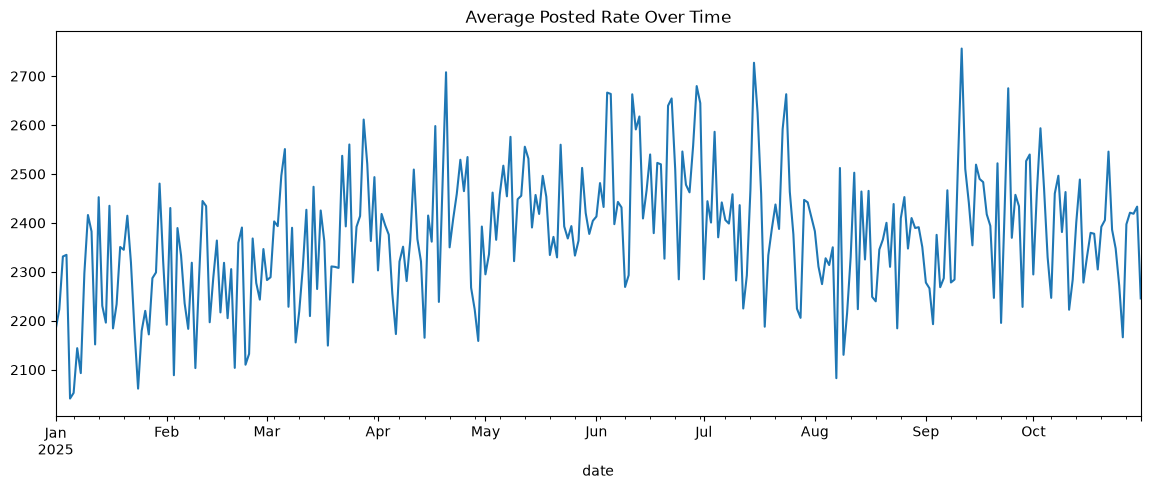

In [15]:
daily["mean"].plot(figsize=(14, 5), title="Average Posted Rate Over Time");

In [24]:
train["rate_per_mile"] = train["posted_rate"] / train["distance"]

train["rate_per_mile"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
1%           1.673521
5%           1.807533
25%          1.986974
50%          2.145348
75%          2.342696
95%          2.735925
99%          3.176940
max         14.125294
Name: rate_per_mile, dtype: float64

In [25]:
train.groupby("equipment")["rate_per_mile"].agg(
    ["count", "mean", "median", "std"]
).round(4)

,count,mean,median,std
equipment,,,,
Dry Van,27202,2.1154,2.0462,0.5381
Flatbed,8753,2.2947,2.2197,0.6102
Reefer,12045,2.3834,2.3115,0.6155


In [26]:
train.nlargest(15, "rate_per_mile")[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "market_index",
        "quote_signal",
        "posted_rate",
        "rate_per_mile"
    ]
]

,pickup,delivery,distance,equipment,weight,date,market_index,quote_signal,posted_rate,rate_per_mile
22254,Greensboro,Cincinnati,314.7,Reefer,-36485.0,2025-05-21,1.37257,1.24215,4445.23,14.125294
36609,Chattanooga,Atlanta,98.4,Reefer,22226.0,2025-08-20,1.03474,2.58457,1386.42,14.089634
870,Tulsa,Baton Rouge,305.6,Reefer,26447.0,2025-01-06,0.80857,2.64181,4069.24,13.315576
17070,Toledo,Dayton,201.5,Flatbed,38714.0,2025-04-18,1.30277,1.44259,2609.34,12.949578
27969,Buffalo,Boston,589.9,Reefer,24951.0,2025-06-25,1.33920,2.58804,7597.52,12.879335
23369,Amarillo,Lubbock,412.4,Flatbed,35494.0,2025-05-28,1.38576,1.40576,5308.96,12.873327
28012,Montgomery,Houston,604.3,Reefer,39690.0,2025-06-25,1.31135,2.76111,7773.37,12.863429
45483,Greensboro,Columbia,153.8,Dry Van,34198.0,2025-10-15,1.00256,1.46388,1971.21,12.816710
1415,Montgomery,Birmingham,198.2,Reefer,25383.0,2025-01-09,0.99663,2.66449,2509.96,12.663774
21968,Jacksonville,Columbia,254.5,Dry Van,32993.0,2025-05-19,1.21285,1.52868,3220.66,12.654853


In [27]:
train.nsmallest(15, "rate_per_mile")[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "market_index",
        "quote_signal",
        "posted_rate",
        "rate_per_mile"
    ]
]

,pickup,delivery,distance,equipment,weight,date,market_index,quote_signal,posted_rate,rate_per_mile
14102,Buffalo,Bakersfield,2536.4,Dry Van,27044.0,2025-03-30,1.03395,1.77264,846.42,0.333709
25798,Albany,Reno,2894.3,Dry Van,32383.0,2025-06-12,1.33841,1.87999,969.83,0.335083
23043,Phoenix,Philadelphia,2983.4,Dry Van,37692.0,2025-05-26,1.16832,2.31695,1047.91,0.351247
46173,Philadelphia,El Paso,2490.9,Dry Van,22411.0,2025-10-20,0.87879,2.40555,880.13,0.353338
508,Las Vegas,Grand Rapids,1976.4,Flatbed,28233.0,2025-01-04,0.86314,1.82202,699.41,0.353881
2511,Buffalo,San Antonio,1644.3,Flatbed,22022.0,2025-01-16,0.99936,1.87307,596.04,0.362489
40600,Fort Wayne,Phoenix,2210.6,Dry Van,24954.0,2025-09-14,0.78281,1.72726,808.74,0.365846
22458,Salt Lake City,Mobile,1632.3,Dry Van,-32048.0,2025-05-22,1.43189,2.10748,599.77,0.367439
22464,Kansas City,Los Angeles,1909.1,Dry Van,32899.0,2025-05-22,1.41012,2.09782,709.46,0.371620
1555,El Paso,New York,2415.0,Dry Van,39284.0,2025-01-10,0.97093,1.83237,911.44,0.377408


In [31]:
monthly = (
    train.groupby(train["date"].dt.to_period("M"))
    .agg(
        mean_rate=("posted_rate", "mean"),
        median_rate=("posted_rate", "median"),
        mean_market=("market_index", "mean"),
        mean_quote=("quote_signal", "mean"),
        count=("posted_rate", "size")
    )
)

monthly.round(2)

,mean_rate,median_rate,mean_market,mean_quote,count
date,,,,,
2025-01,2255.97,1915.20,0.93,2.07,4918
2025-02,2273.80,1994.25,1.00,2.10,4337
2025-03,2372.27,2022.92,1.07,2.18,5036
2025-04,2372.16,2044.24,1.21,1.96,4819
2025-05,2421.78,2065.51,1.30,1.91,4913
2025-06,2497.03,2120.22,1.28,2.30,4783
2025-07,2415.16,2059.14,1.20,1.92,4912
2025-08,2338.41,2015.73,0.98,2.05,4759
2025-09,2406.37,2057.13,0.89,2.20,4670


In [34]:
features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate",
    "rate_per_mile"
]

train[features].corr().round(4)

,distance,weight,market_index,quote_signal,posted_rate,rate_per_mile
distance,1.0000,0.0025,-0.0022,-0.0572,0.9085,-0.3346
weight,0.0025,1.0000,-0.0013,0.0082,0.0348,0.0745
market_index,-0.0022,-0.0013,1.0000,-0.0678,0.0342,0.0835
quote_signal,-0.0572,0.0082,-0.0678,1.0000,-0.0399,0.0493
posted_rate,0.9085,0.0348,0.0342,-0.0399,1.0000,0.0031
rate_per_mile,-0.3346,0.0745,0.0835,0.0493,0.0031,1.0000


In [35]:
train.groupby("equipment")["rate_per_mile"].mean().round(4)

equipment
Dry Van    2.1154
Flatbed    2.2947
Reefer     2.3834
Name: rate_per_mile, dtype: float64

## 6. Categorical and Numeric Features

We review feature distributions, categorical cardinalities, route statistics, and compare training features with validation features to check for unseen categories or distribution shifts.

In [8]:
numeric_cols = train.select_dtypes(include=np.number).columns

train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [10]:
for col in ["pickup", "delivery", "equipment"]:
    print(f"\n--- {col} ---")
    print("unique:", train[col].nunique())
    print(train[col].value_counts().head(20))


--- pickup ---
unique: 64
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
San Antonio       972
Philadelphia      946
Los Angeles       945
Milwaukee         944
Tucson            944
Name: count, dtype: int64

--- delivery ---
unique: 64
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Cincinnati       1084
Columbia         1071
Nashville        1064
Tucson            997
Shreveport        983
Kansas City       980
San Antonio       965
Philadelphia      959
Los Angeles       955
Syracuse          926
Name: count, dtype: in

In [18]:
print("Train:", sorted(train["equipment"].unique()))
print("Validation:", sorted(validation["equipment"].unique()))
print("December:", sorted(december["equipment"].unique()))

Train: ['Dry Van', 'Flatbed', 'Reefer']
Validation: ['Dry Van', 'Flatbed', 'Reefer']
December: ['Dry Van']


In [19]:
print("Train pickups:", train["pickup"].nunique())
print("Validation pickups:", validation["pickup"].nunique())

print("Train deliveries:", train["delivery"].nunique())
print("Validation deliveries:", validation["delivery"].nunique())

Train pickups: 64
Validation pickups: 72
Train deliveries: 64
Validation deliveries: 72


In [20]:
train_pickups = set(train["pickup"].unique())
train_deliveries = set(train["delivery"].unique())

unseen_pickups = set(validation["pickup"].unique()) - train_pickups
unseen_deliveries = set(validation["delivery"].unique()) - train_deliveries

print("Unseen validation pickups:", unseen_pickups)
print("Unseen validation deliveries:", unseen_deliveries)

Unseen validation pickups: {'Jackson', 'Charlotte', 'Knoxville', 'Norfolk', 'San Diego', 'Laredo', 'Chicago', 'Allentown'}
Unseen validation deliveries: {'Jackson', 'Charlotte', 'Knoxville', 'Norfolk', 'San Diego', 'Laredo', 'Chicago', 'Allentown'}


In [21]:
print("Unseen validation equipment:",
      set(validation["equipment"].unique()) - set(train["equipment"].unique()))

Unseen validation equipment: set()


In [22]:
route_stats = (
    train.groupby(["pickup", "delivery"])
    .agg(
        observations=("posted_rate", "size"),
        mean_rate=("posted_rate", "mean"),
        median_rate=("posted_rate", "median"),
        mean_distance=("distance", "mean")
    )
    .sort_values("observations", ascending=False)
)

route_stats.head(20)

observations    mean_rate  median_rate  \
pickup        delivery                                                
Columbia      Oklahoma City            39  2330.734615     2327.430   
Phoenix       Shreveport               39  3507.618462     3554.430   
Lexington     Atlanta                  39   560.106154      553.630   
Fort Wayne    Philadelphia             38  1681.032632     1708.835   
Shreveport    Hartford                 37  2867.768108     2812.520   
Fort Wayne    Hartford                 37  1938.657297     1725.990   
Richmond      Oklahoma City            37  3093.435946     3126.490   
              Phoenix                  37  5190.194595     5010.880   
Lexington     Kansas City              37  1042.474595     1029.800   
              Cincinnati               37   396.691892      377.100   
Fort Wayne    Cincinnati               36   871.521111      857.150   
Mobile        Phoenix                  36  4180.469167     3842.000   
Richmond      Cincinnati               35  1472.597143     1445.430   
Oklahoma City Nashville                35  1737.457143     1744.960   
Hartford      Baton Rouge              35  3102.180571     3101.260   
Oklahoma City Atlanta                  35  1895.603714     1909.990   
              Columbia                 35  2333.602857     2279.320   
Bakersfield   Hartford                 35  5998.482286     5402.590   
Oklahoma City Mobile                   35  1517.043143     1644.700   
Philadelphia  Lexington                35  1708.174857     1691.690   

                             mean_distance  
pickup        delivery                      
Columbia      Oklahoma City    1061.415385  
Phoenix       Shreveport       1668.494872  
Lexington     Atlanta           208.943590  
Fort Wayne    Philadelphia      791.602632  
Shreveport    Hartford         1433.270270  
Fort Wayne    Hartford          832.602703  
Richmond      Oklahoma City    1526.840541  
              Phoenix          2705.283784  
Lexington     Kansas City       447.886486  
              Cincinnati        133.327027  
Fort Wayne    Cincinnati        361.000000  
Mobile        Phoenix          1932.205556  
Richmond      Cincinnati        655.071429  
Oklahoma City Nashville         769.577143  
Hartford      Baton Rouge      1527.562857  
Oklahoma City Atlanta           869.702857  
              Columbia         1063.408571  
Bakersfield   Hartford         2881.462857  
Oklahoma City Mobile            718.731429  
Philadelphia  Lexington         793.800000

In [23]:
route_distance = (
    train.groupby(["pickup", "delivery"])["distance"]
    .agg(["count", "nunique", "min", "max"])
)

route_distance.sort_values("nunique", ascending=False).head(20)

,,count,nunique,min,max
pickup,delivery,,,,
Fort Wayne,Philadelphia,38,38,767.8,813.7
Lexington,Kansas City,37,37,426.9,469.1
Columbia,Oklahoma City,39,37,1028.6,1102.1
Shreveport,Hartford,37,37,1385.6,1479.6
Lexington,Atlanta,39,37,184.9,228.4
Phoenix,Shreveport,39,37,1632.0,1711.0
Richmond,Oklahoma City,37,37,1486.3,1570.9
Mobile,Phoenix,36,36,1880.0,2006.2
Fort Wayne,Hartford,37,36,784.9,876.2


In [32]:
compare = pd.DataFrame({
    "train_mean": train[["distance", "weight", "market_index", "quote_signal"]].mean(),
    "validation_mean": validation[["distance", "weight", "market_index", "quote_signal"]].mean(),
})

compare["pct_change"] = (
    (compare["validation_mean"] - compare["train_mean"])
    / compare["train_mean"] * 100
)

compare.round(3)

,train_mean,validation_mean,pct_change
distance,1135.857,1141.773,0.521
weight,31028.844,30506.636,-1.683
market_index,1.083,0.927,-14.443
quote_signal,2.062,2.051,-0.540


In [33]:
print("Training dates:")
print(train["date"].min(), train["date"].max())

print("\nValidation dates:")
print(validation["date"].min(), validation["date"].max())

Training dates:
2025-01-01 00:00:00 2025-10-31 00:00:00

Validation dates:
2025-11-01 00:00:00 2025-12-31 00:00:00


In [6]:
from src.data import load_train_test
from src.validation import temporal_train_valid_split

train_df = load_train_test()

X_train, y_train, X_valid, y_valid = temporal_train_valid_split(
    train_df,
    cutoff_date="2025-10-01",
    target_column="posted_rate",
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))

print("\nTraining dates:")
print(X_train["date"].min(), "→", X_train["date"].max())

print("\nValidation dates:")
print(X_valid["date"].min(), "→", X_valid["date"].max())

Training rows: 43147
Validation rows: 4853

Training dates:
2025-01-01 00:00:00 → 2025-09-30 00:00:00

Validation dates:
2025-10-01 00:00:00 → 2025-10-31 00:00:00


## 7. Key Findings

Here is a summary of the main points from this data audit:

- **Dataset sizes**: The training set contains 48,000 labeled loads from January 1, 2025 to October 31, 2025. The validation set contains 12,000 unlabeled loads covering November 1, 2025 to December 31, 2025. The December test set contains 31 daily loads for a single lane (Lexington to Fort Wayne).
- **Missing values**: In the training set, weight is missing in 300 rows (0.62%) and market index is missing in 374 rows (0.78%). In the validation set, weight is missing in 165 rows (1.38%). All other columns have complete data.
- **Negative weights**: 292 training rows (0.61%) and 145 validation rows (1.21%) have negative weight values across all three equipment types (Dry Van: 178, Flatbed: 63, Reefer: 51 in training).
- **Posted rate distribution**: Posted rates range from $57.22 to $25,533.00, with a median of $2,030.76 and a mean of $2,373.98. While 99% of rates are under $5,973, there is a heavy right tail with rates extending well above $10,000.
- **Feature relationships**: Distance is the primary driver of posted rate, with a Pearson correlation of 0.9085. Average rate per mile is around $2.22 across all loads, with slight differences by equipment type (Reefer highest, Flatbed middle, Dry Van lowest).
- **Categorical coverage**: Training has 64 pickup and 64 delivery cities. The validation set introduces 8 new cities not seen in training, which means the model pipeline must handle unseen categories cleanly. Equipment types are consistent across all files.